In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

https://www.kaggle.com/datasets/ifteshanajnin/carinsuranceclaimprediction-classification

# FUNCTIONS

All functions used in this project are in this section

In [2]:
#Read dataset, check for null and duplicates
def read_dataset():
    
    data = pd.read_csv("train.csv")
    nrow = len(data.index)
    ncol = len(data.columns)

    print("The dataset contains", format(nrow, ",d"), "rows and", ncol, "columns.")
    
    #Check for null values
    if ((data.isna().sum()).sum()) > 0:
        print("There are null items in the dataset")
    else:
        print("There are no null items in the dataset")
        
    #Check for duplicates
    
    #col_names = ["Country", "Year", "Status"]
    #(data.duplicated(subset=col_names)).sum()

    if (data.duplicated().sum()) > 0:
        print("There are duplicates in the dataset")
    else:
        print("There are no duplicates in the dataset")
        
    return data



#Function to categorize data into numeric and categorical
def categorize_data(data):
    
    numeric=[]
    categorical=[]
    numeric_dtypes = ["int64", "int32", "float64", "float32"]

    for i in range (len(data.columns)):
        if data[data.columns[i]].dtype in numeric_dtypes:
            numeric.append(data.columns[i])
        else:
            categorical.append(data.columns[i])
            
    return numeric, categorical

    
#Function to check for outliers
def outliers_check(data, numeric):
    outliers_sum =[]

    for i in range(len(numeric_cols)):
        Q1 = data[numeric_cols[i]].quantile(0.25)
        Q3 = data[numeric_cols[i]].quantile(0.75)
        IQR = Q3 - Q1
        outliers = (data[numeric_cols[i]] < (Q1 - 1.5 * IQR)) | (data[numeric_cols[i]] > (Q3 + 1.5 * IQR))
        print(numeric_cols[i], "",outliers.sum())
        outliers_sum.append(outliers.sum())

    return outliers.sum()


def remove_duplicates(data):
    duplicated_sum = data.duplicated().sum()
    if duplicated_sum == 0:
        print("Number of duplicated rows in dataset =", duplicated_sum)
        return data
    else:
        print("Number of duplicated rows in dataset =", duplicated_sum)
        data = data[~data.duplicated()]
        print("Duplicated rows have been removed")
        return data

    
    
def oneHotEncoding(data, categorical):

    encoder = OneHotEncoder(sparse=False, drop='first')  # 'drop' parameter removes one of the dummy variables to avoid multicollinearity

    encoded_data = encoder.fit_transform(data[categorical_cols])

    data_encoded = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))

    data_final = pd.concat([data.drop(columns=categorical_cols), data_encoded], axis=1)

    return data_final

# EDA

In [3]:
data = read_dataset()

The dataset contains 58,592 rows and 44 columns.
There are no null items in the dataset
There are no duplicates in the dataset


In [4]:
pd.set_option('display.max_columns', None)

(data).head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

In [6]:
#Summary statistics of the dataset
data.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,3.137066,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,1.832641,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


In [7]:
#Class imbalance
data['is_claim'].value_counts()

0    54844
1     3748
Name: is_claim, dtype: int64

In [8]:
#Max_torque and max_power columns should be numeric but are displayed as categorical beause of the strings in the dataset
#The columns will be separated from "rpm" and converted to numeric columns

data_cleaned = data

data_cleaned[['max_torque_nm', 'max_torque_rpm']] = data_cleaned['max_torque'].str.split('@', expand=True)
data_cleaned[['max_power_bhp', 'max_power_rpm']] = data_cleaned['max_power'].str.split('@', expand=True)

data_cleaned['max_torque_nm'] = (data_cleaned['max_torque_nm'].str.replace('Nm', '')).astype('float64') 
data_cleaned['max_torque_rpm'] = (data_cleaned['max_torque_rpm'].str.replace('rpm', '')).astype('int64')
data_cleaned['max_power_bhp'] = (data_cleaned['max_power_bhp'].str.replace('bhp', '')).astype('float64')
data_cleaned['max_power_rpm'] = (data_cleaned['max_power_rpm'].str.replace('rpm', '')).astype('int64')

data_cleaned = data_cleaned.drop(columns=['policy_id', 'max_torque', 'max_power'])

In [9]:
data_cleaned.head()

,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim,max_torque_nm,max_torque_rpm,max_power_bhp,max_power_rpm
0,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0,60.0,3500,40.36,6000
1,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0,60.0,3500,40.36,6000
2,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0,60.0,3500,40.36,6000
3,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0,113.0,4400,88.50,6000
4,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0,91.0,4250,67.06,5500


In [10]:
#Categorize data into numeric and categorical
numeric_cols, categorical_cols = categorize_data(data_cleaned)

# Visualisations

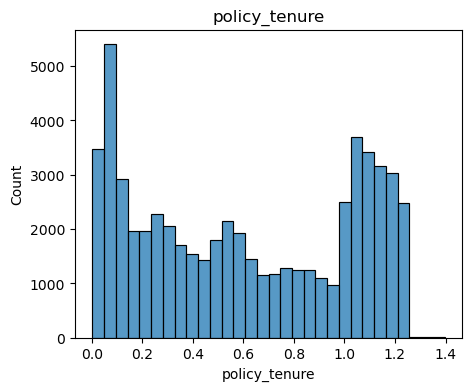

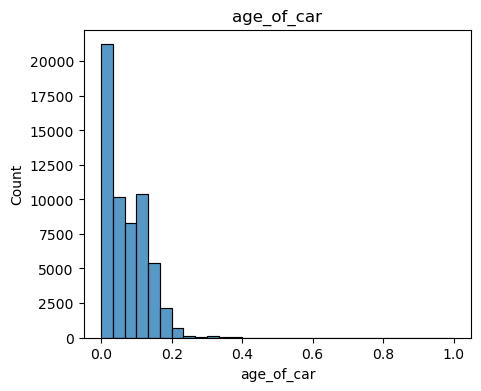

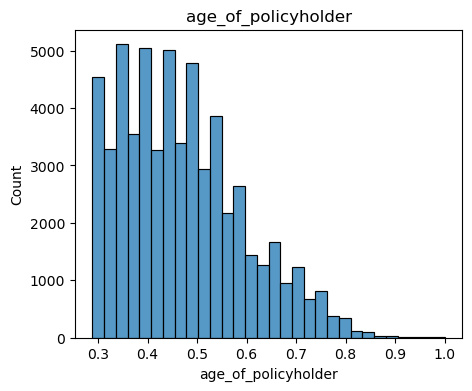

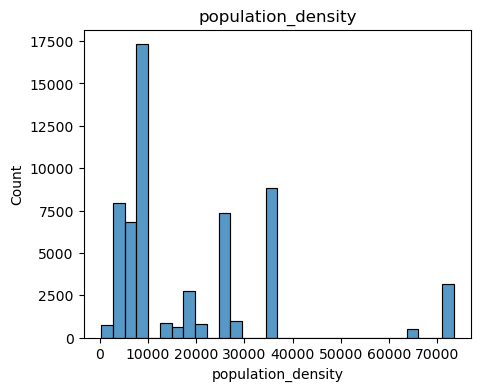

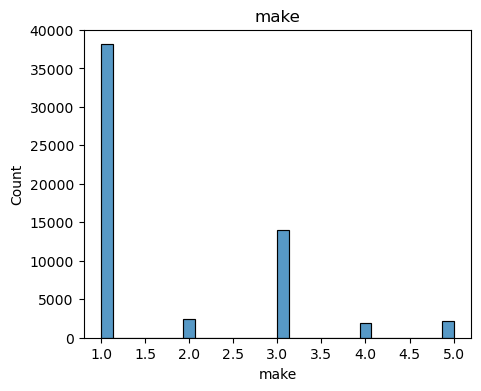

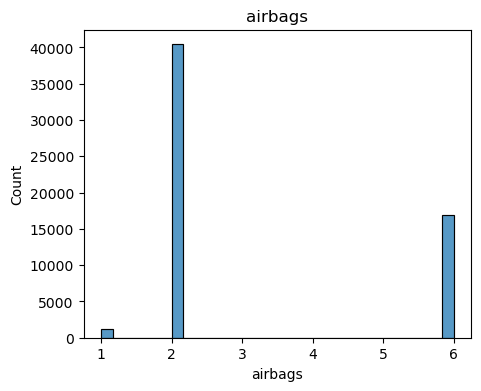

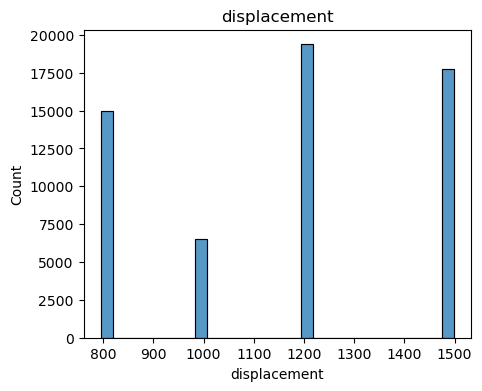

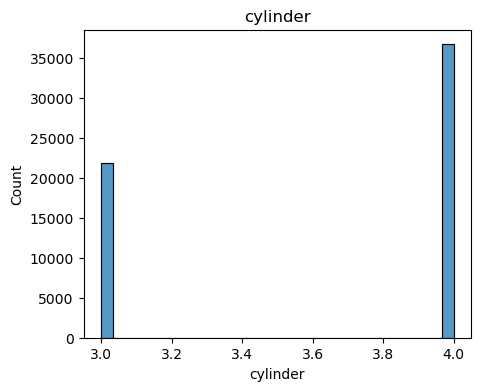

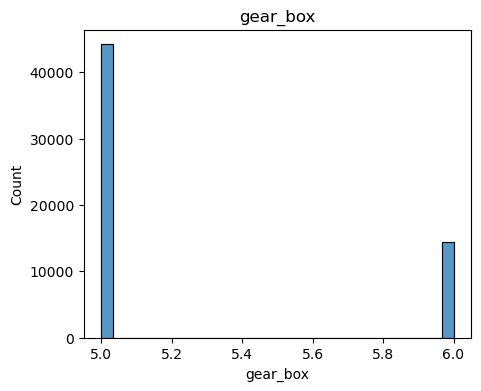

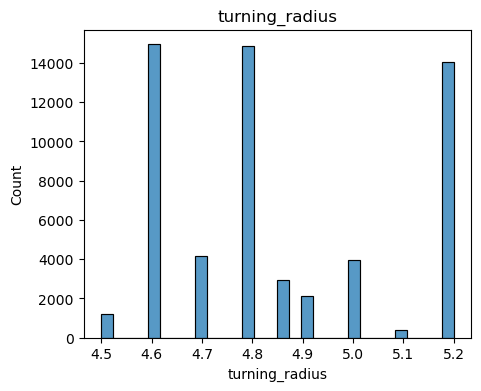

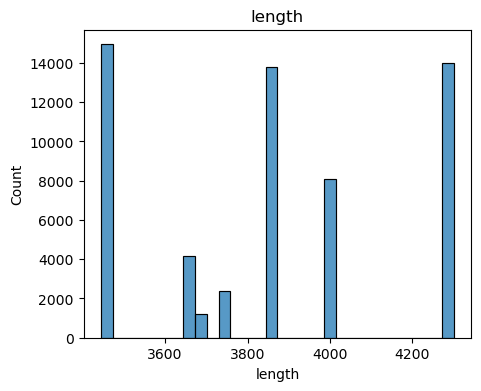

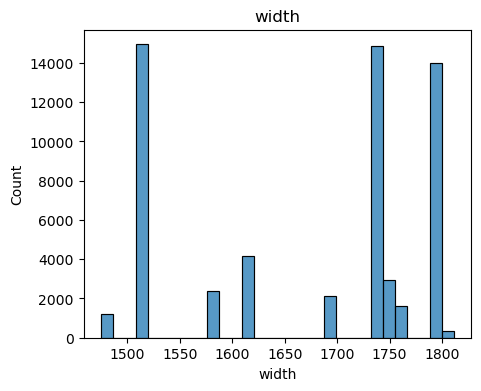

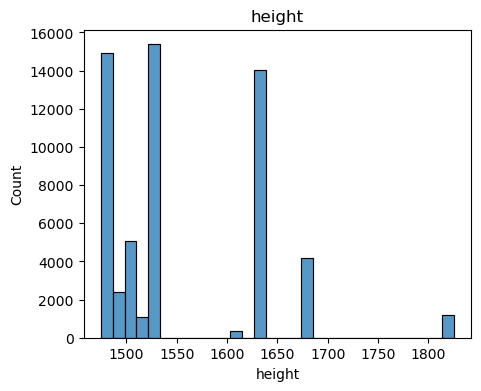

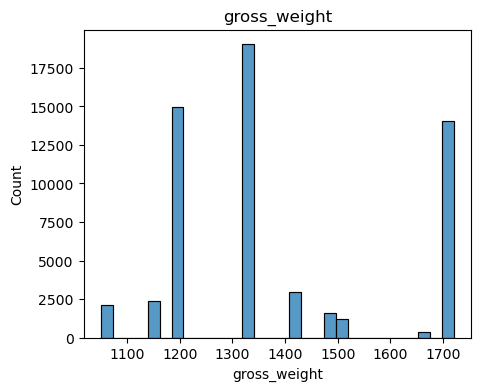

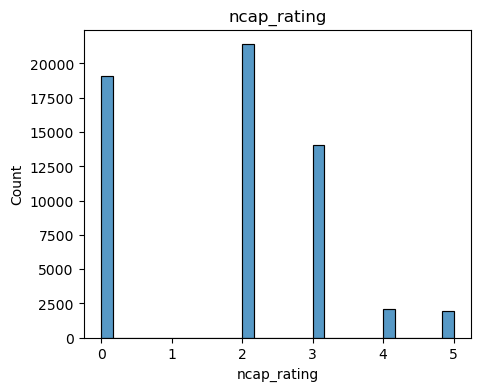

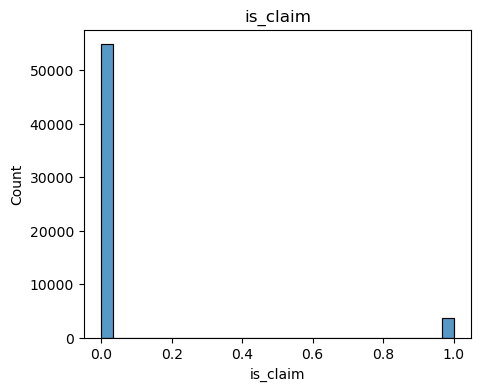

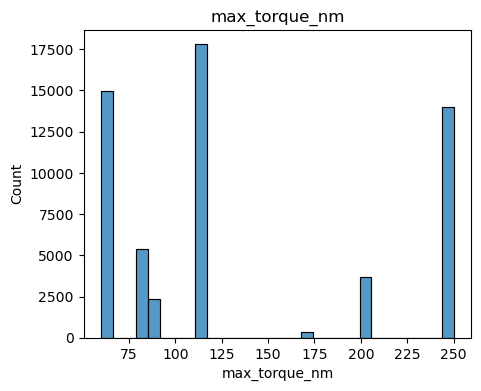

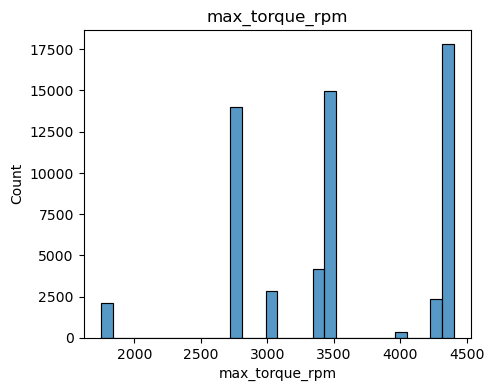

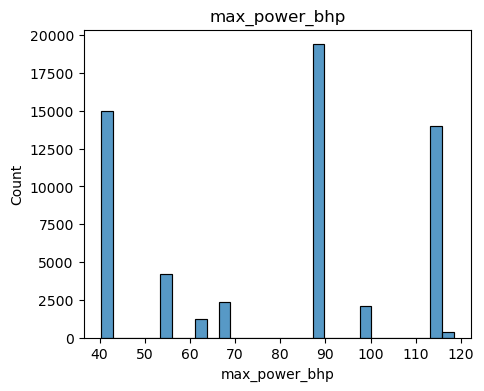

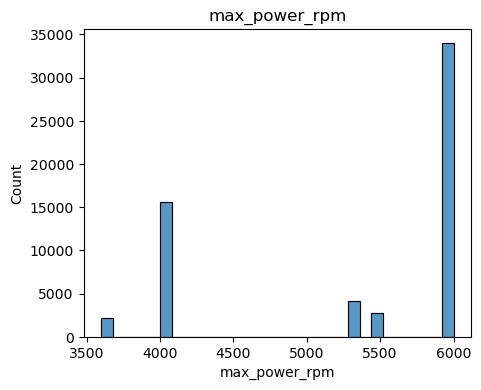

In [11]:
#Check distributions of numeric columns
for i in range (len(numeric_cols)):
    plt.figure(figsize=(5,4))
    sns.histplot(data_cleaned[numeric_cols[i]], bins=30)
    plt.title(numeric_cols[i])

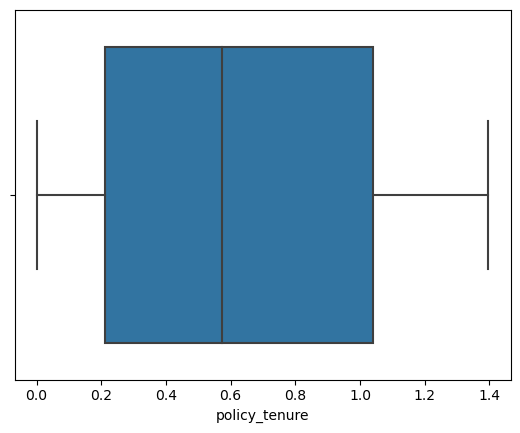

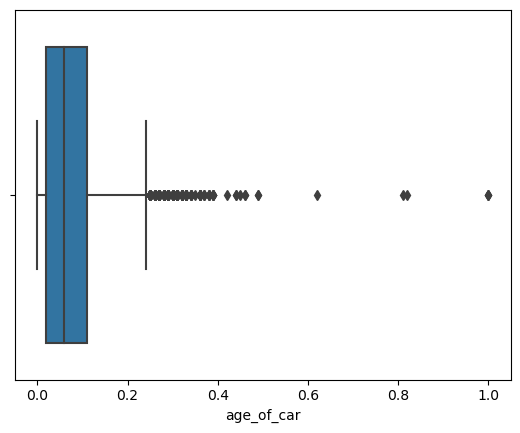

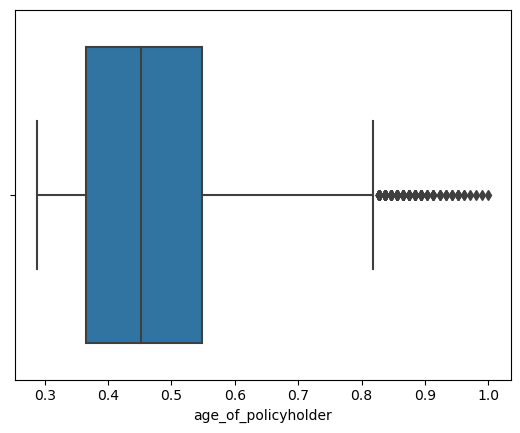

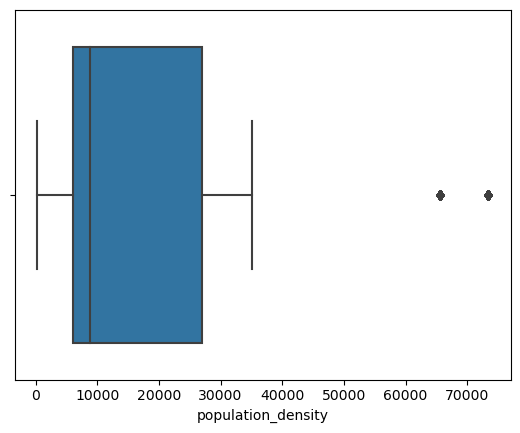

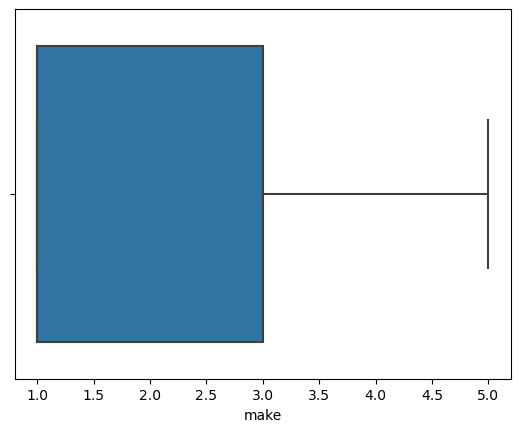

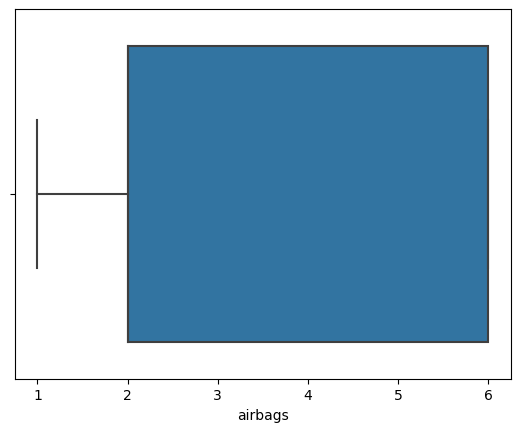

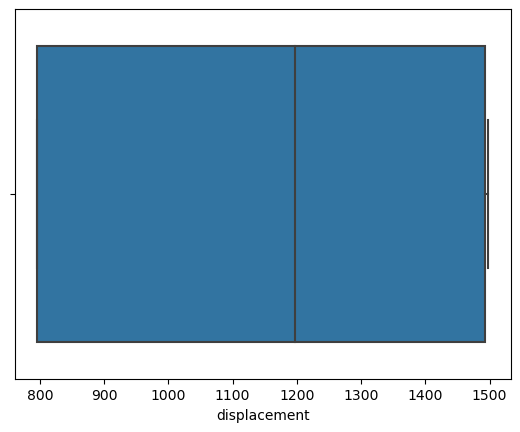

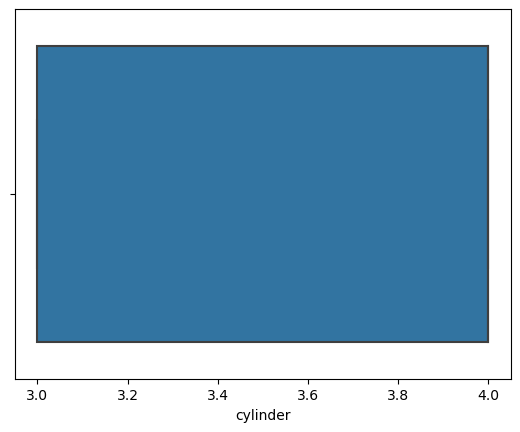

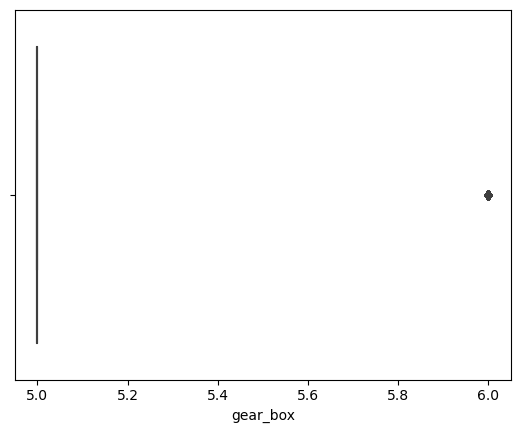

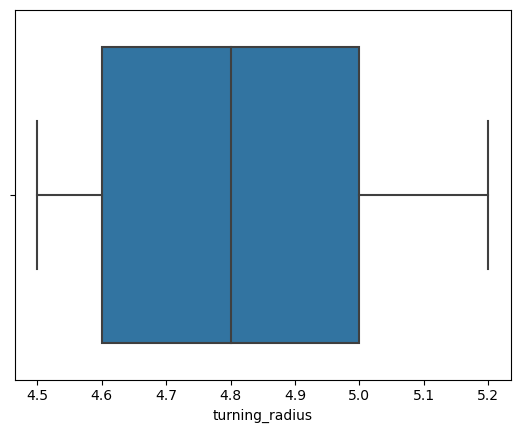

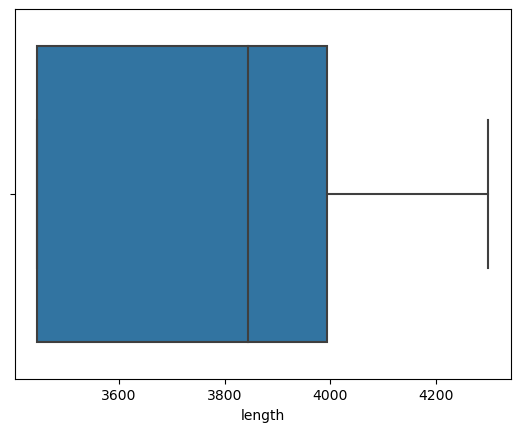

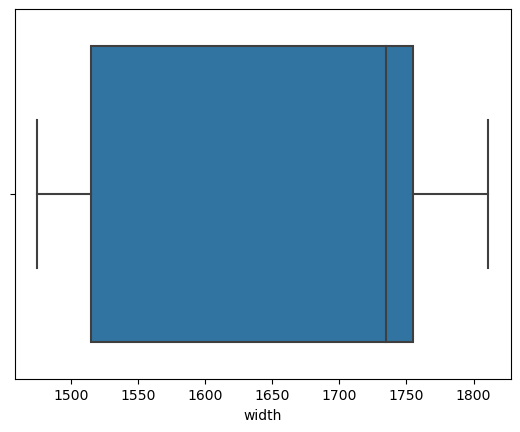

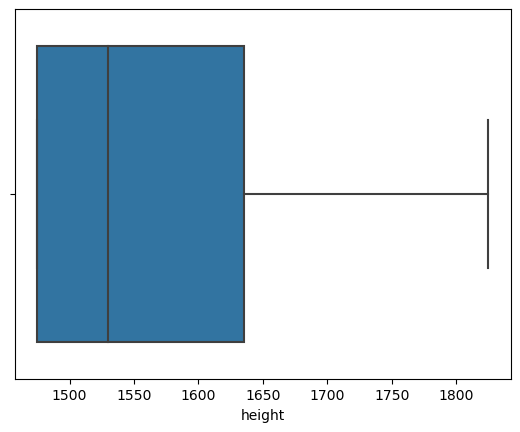

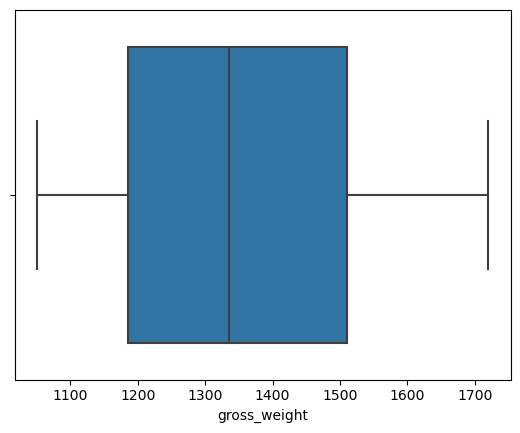

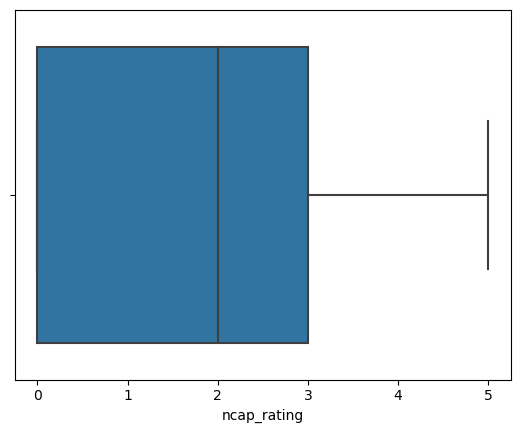

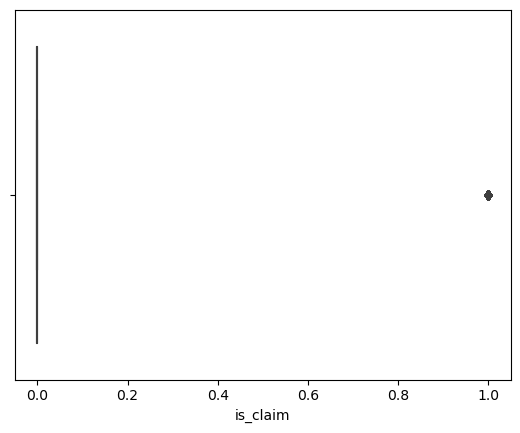

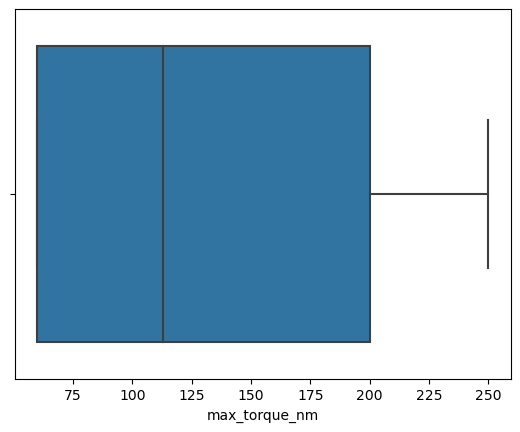

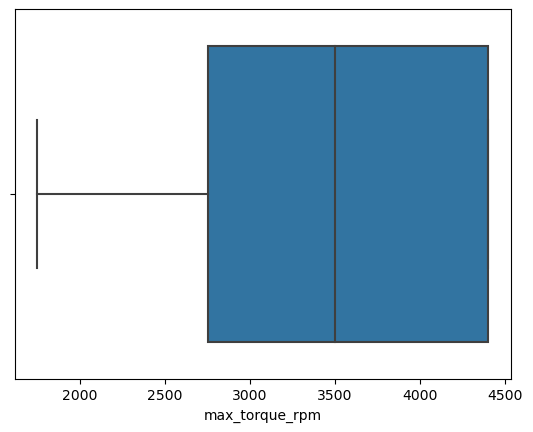

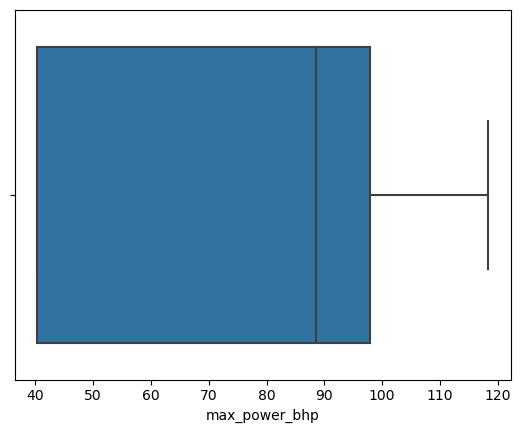

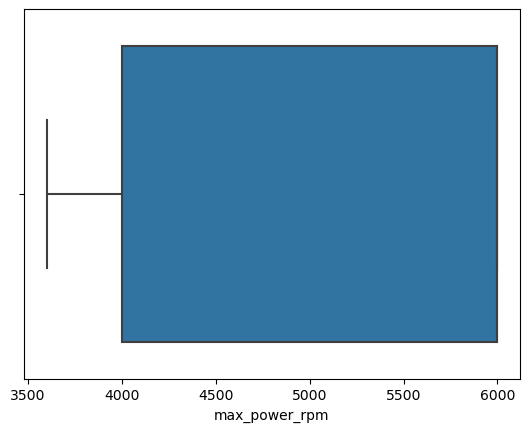

In [12]:
#Box plots for numeric columns
for i in range (len(numeric_cols)):
    plt.figure()
    sns.boxplot(x=data_cleaned[numeric_cols[i]], data=data)

C:\Users\amych\AppData\Local\Temp\ipykernel_14964\620551798.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


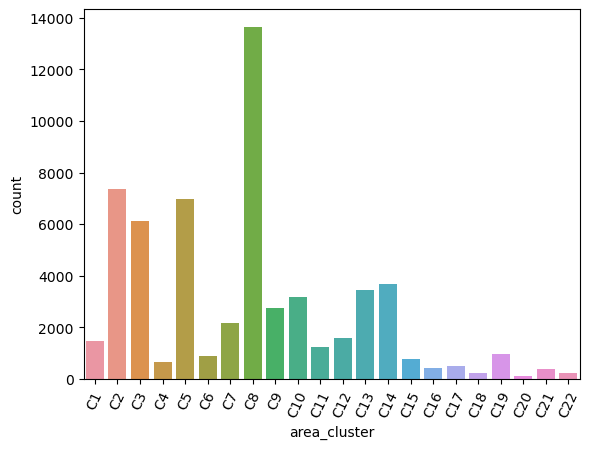

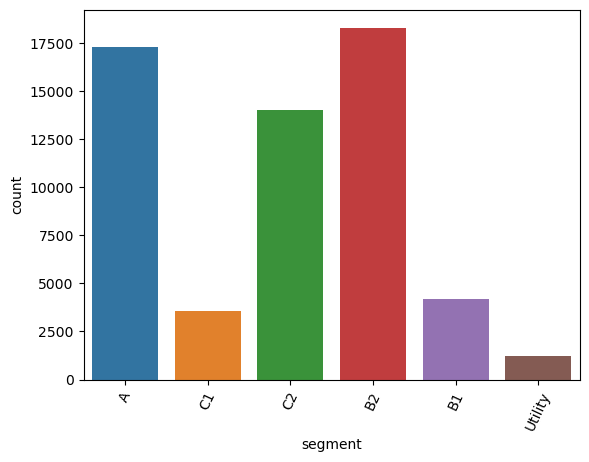

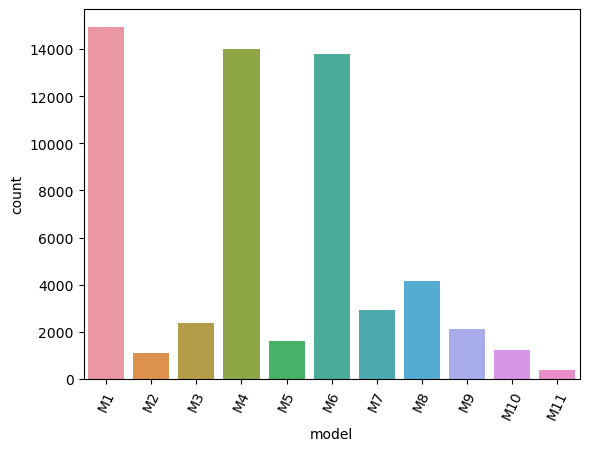

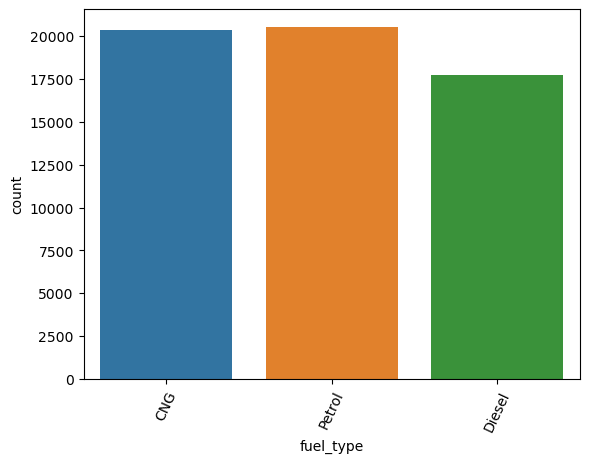

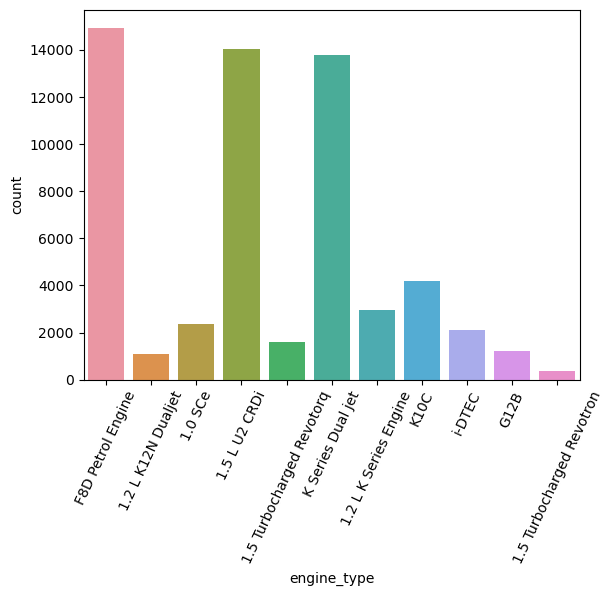

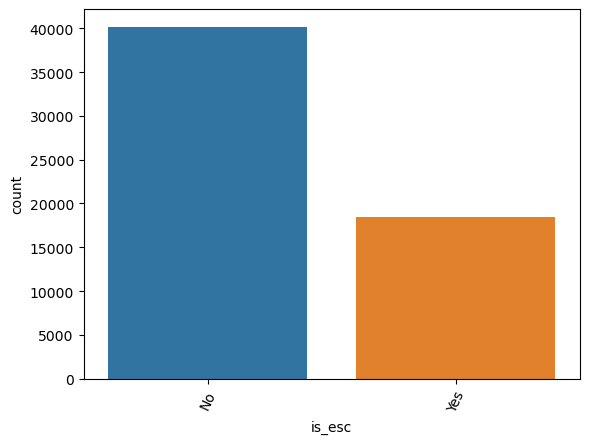

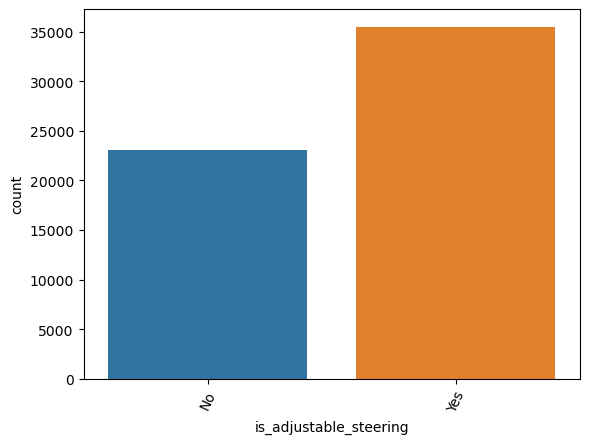

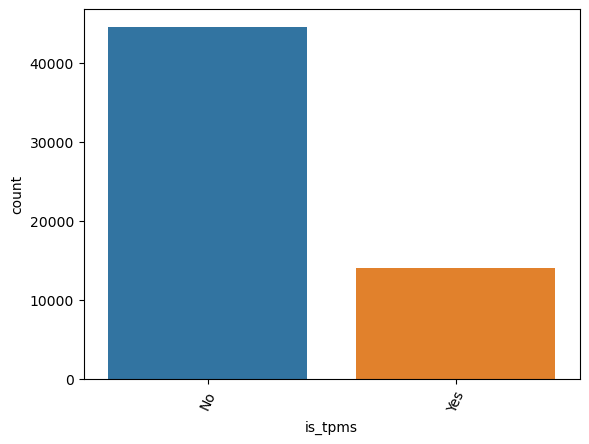

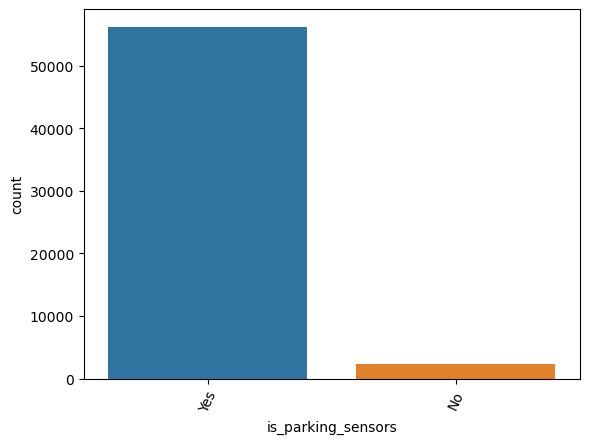

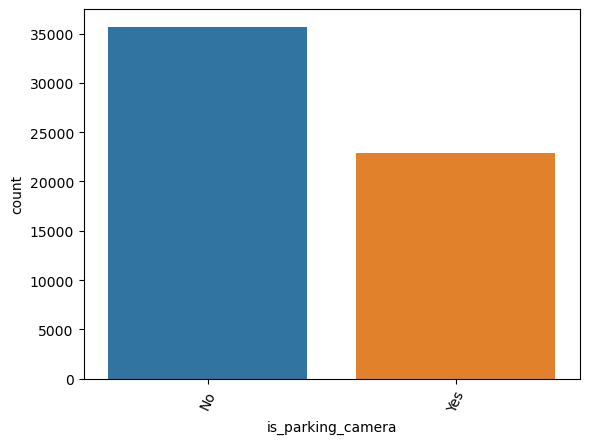

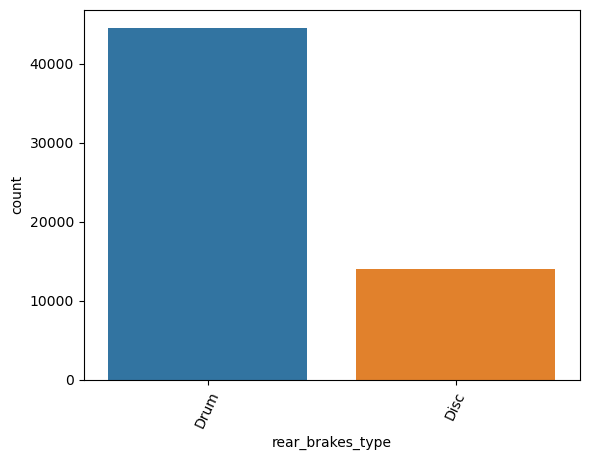

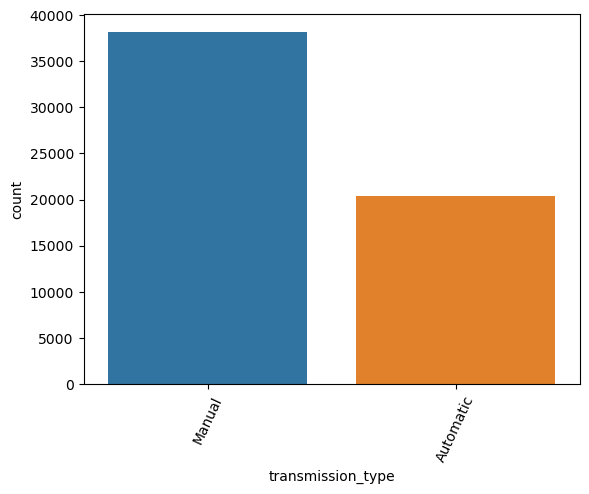

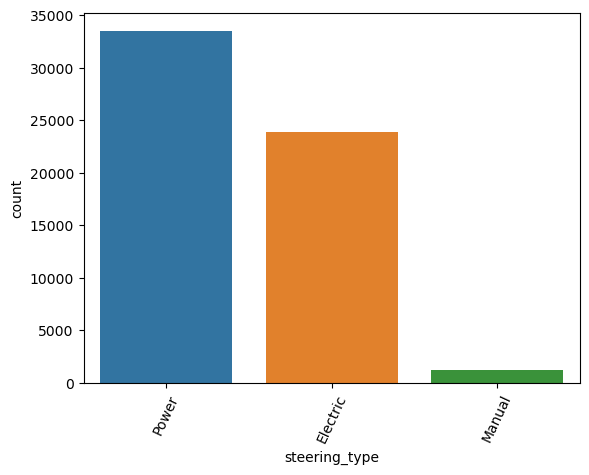

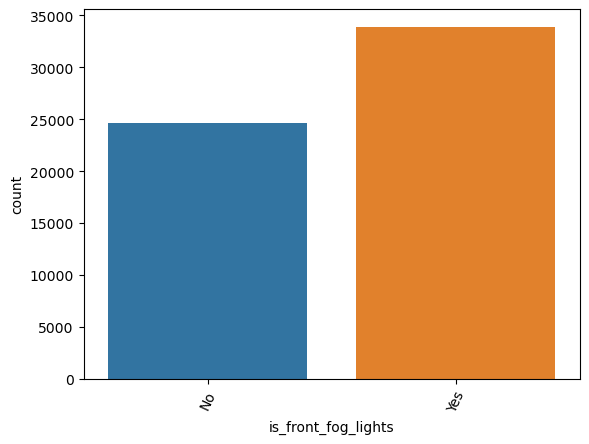

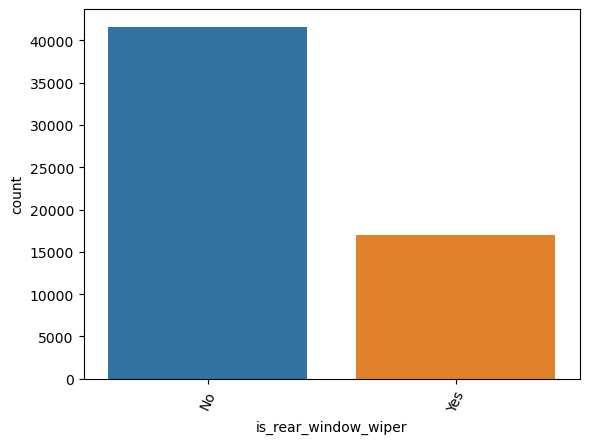

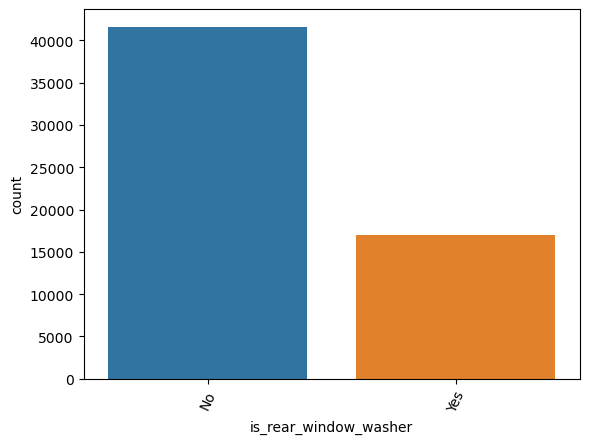

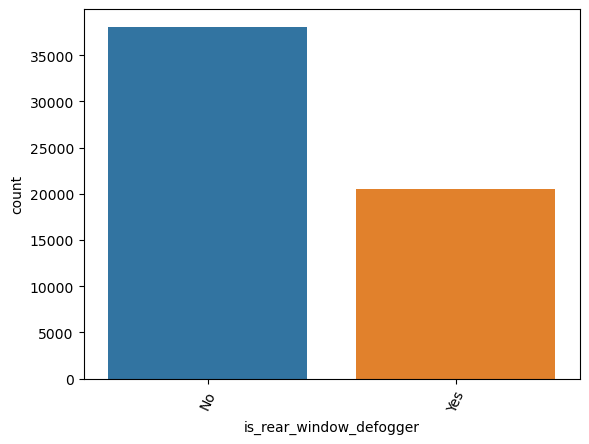

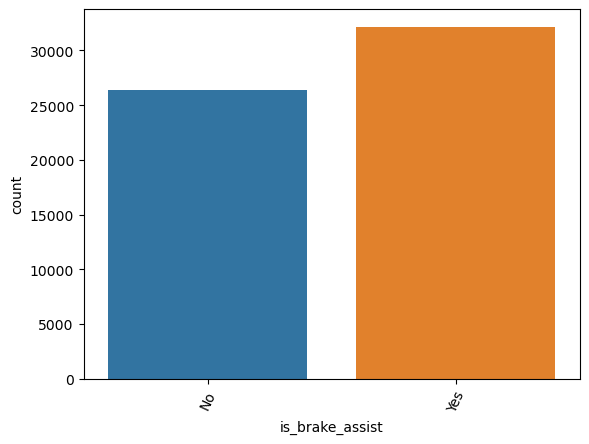

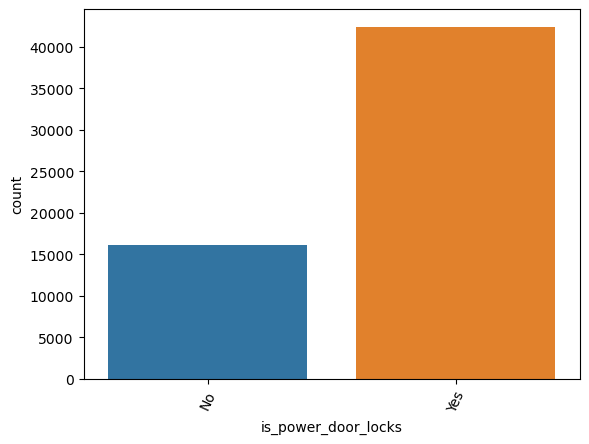

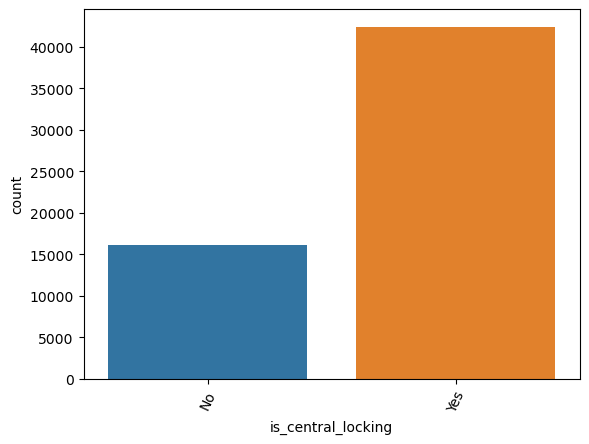

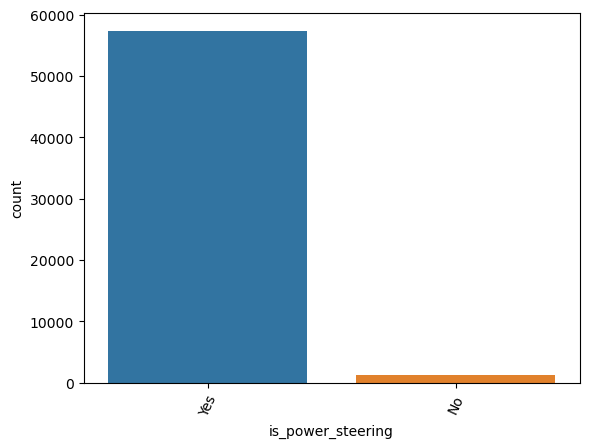

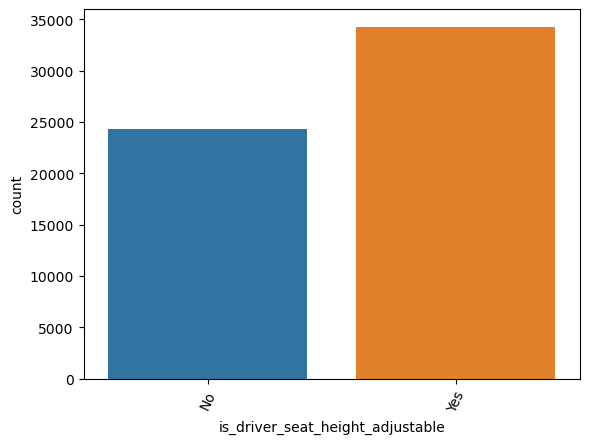

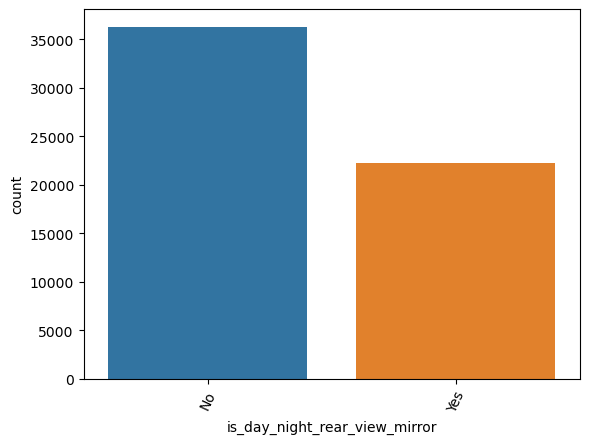

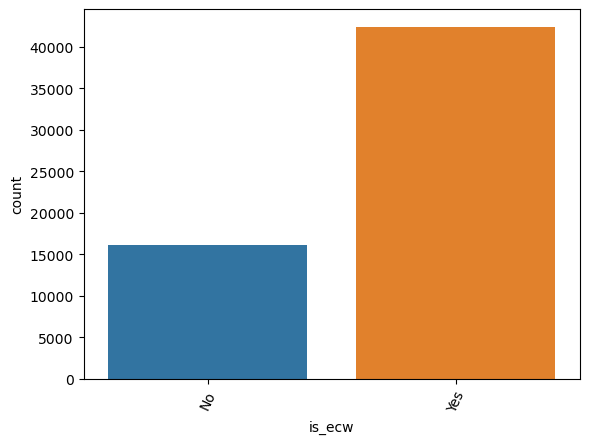

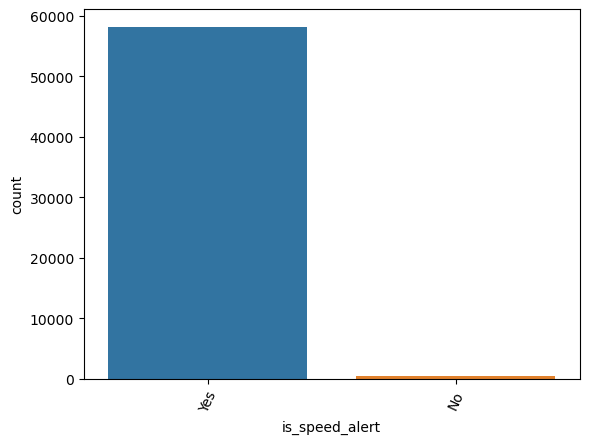

In [13]:
#Bar plots for categorical columns
for i in range (len(categorical_cols)):
    plt.figure()
    sns.countplot(x=data_cleaned[categorical_cols[i]], data=data_cleaned)
    plt.xticks(rotation=65) 

In [11]:
#Check for outliers
outliers = outliers_check(data_cleaned, numeric_cols)

policy_tenure  0
age_of_car  269
age_of_policyholder  221
population_density  3647
make  0
airbags  0
displacement  0
cylinder  0
gear_box  14381
turning_radius  0
length  0
width  0
height  0
gross_weight  0
ncap_rating  0
is_claim  3748
max_torque_nm  0
max_torque_rpm  0
max_power_bhp  0
max_power_rpm  0


# Correlation and Dimensionality Reduction

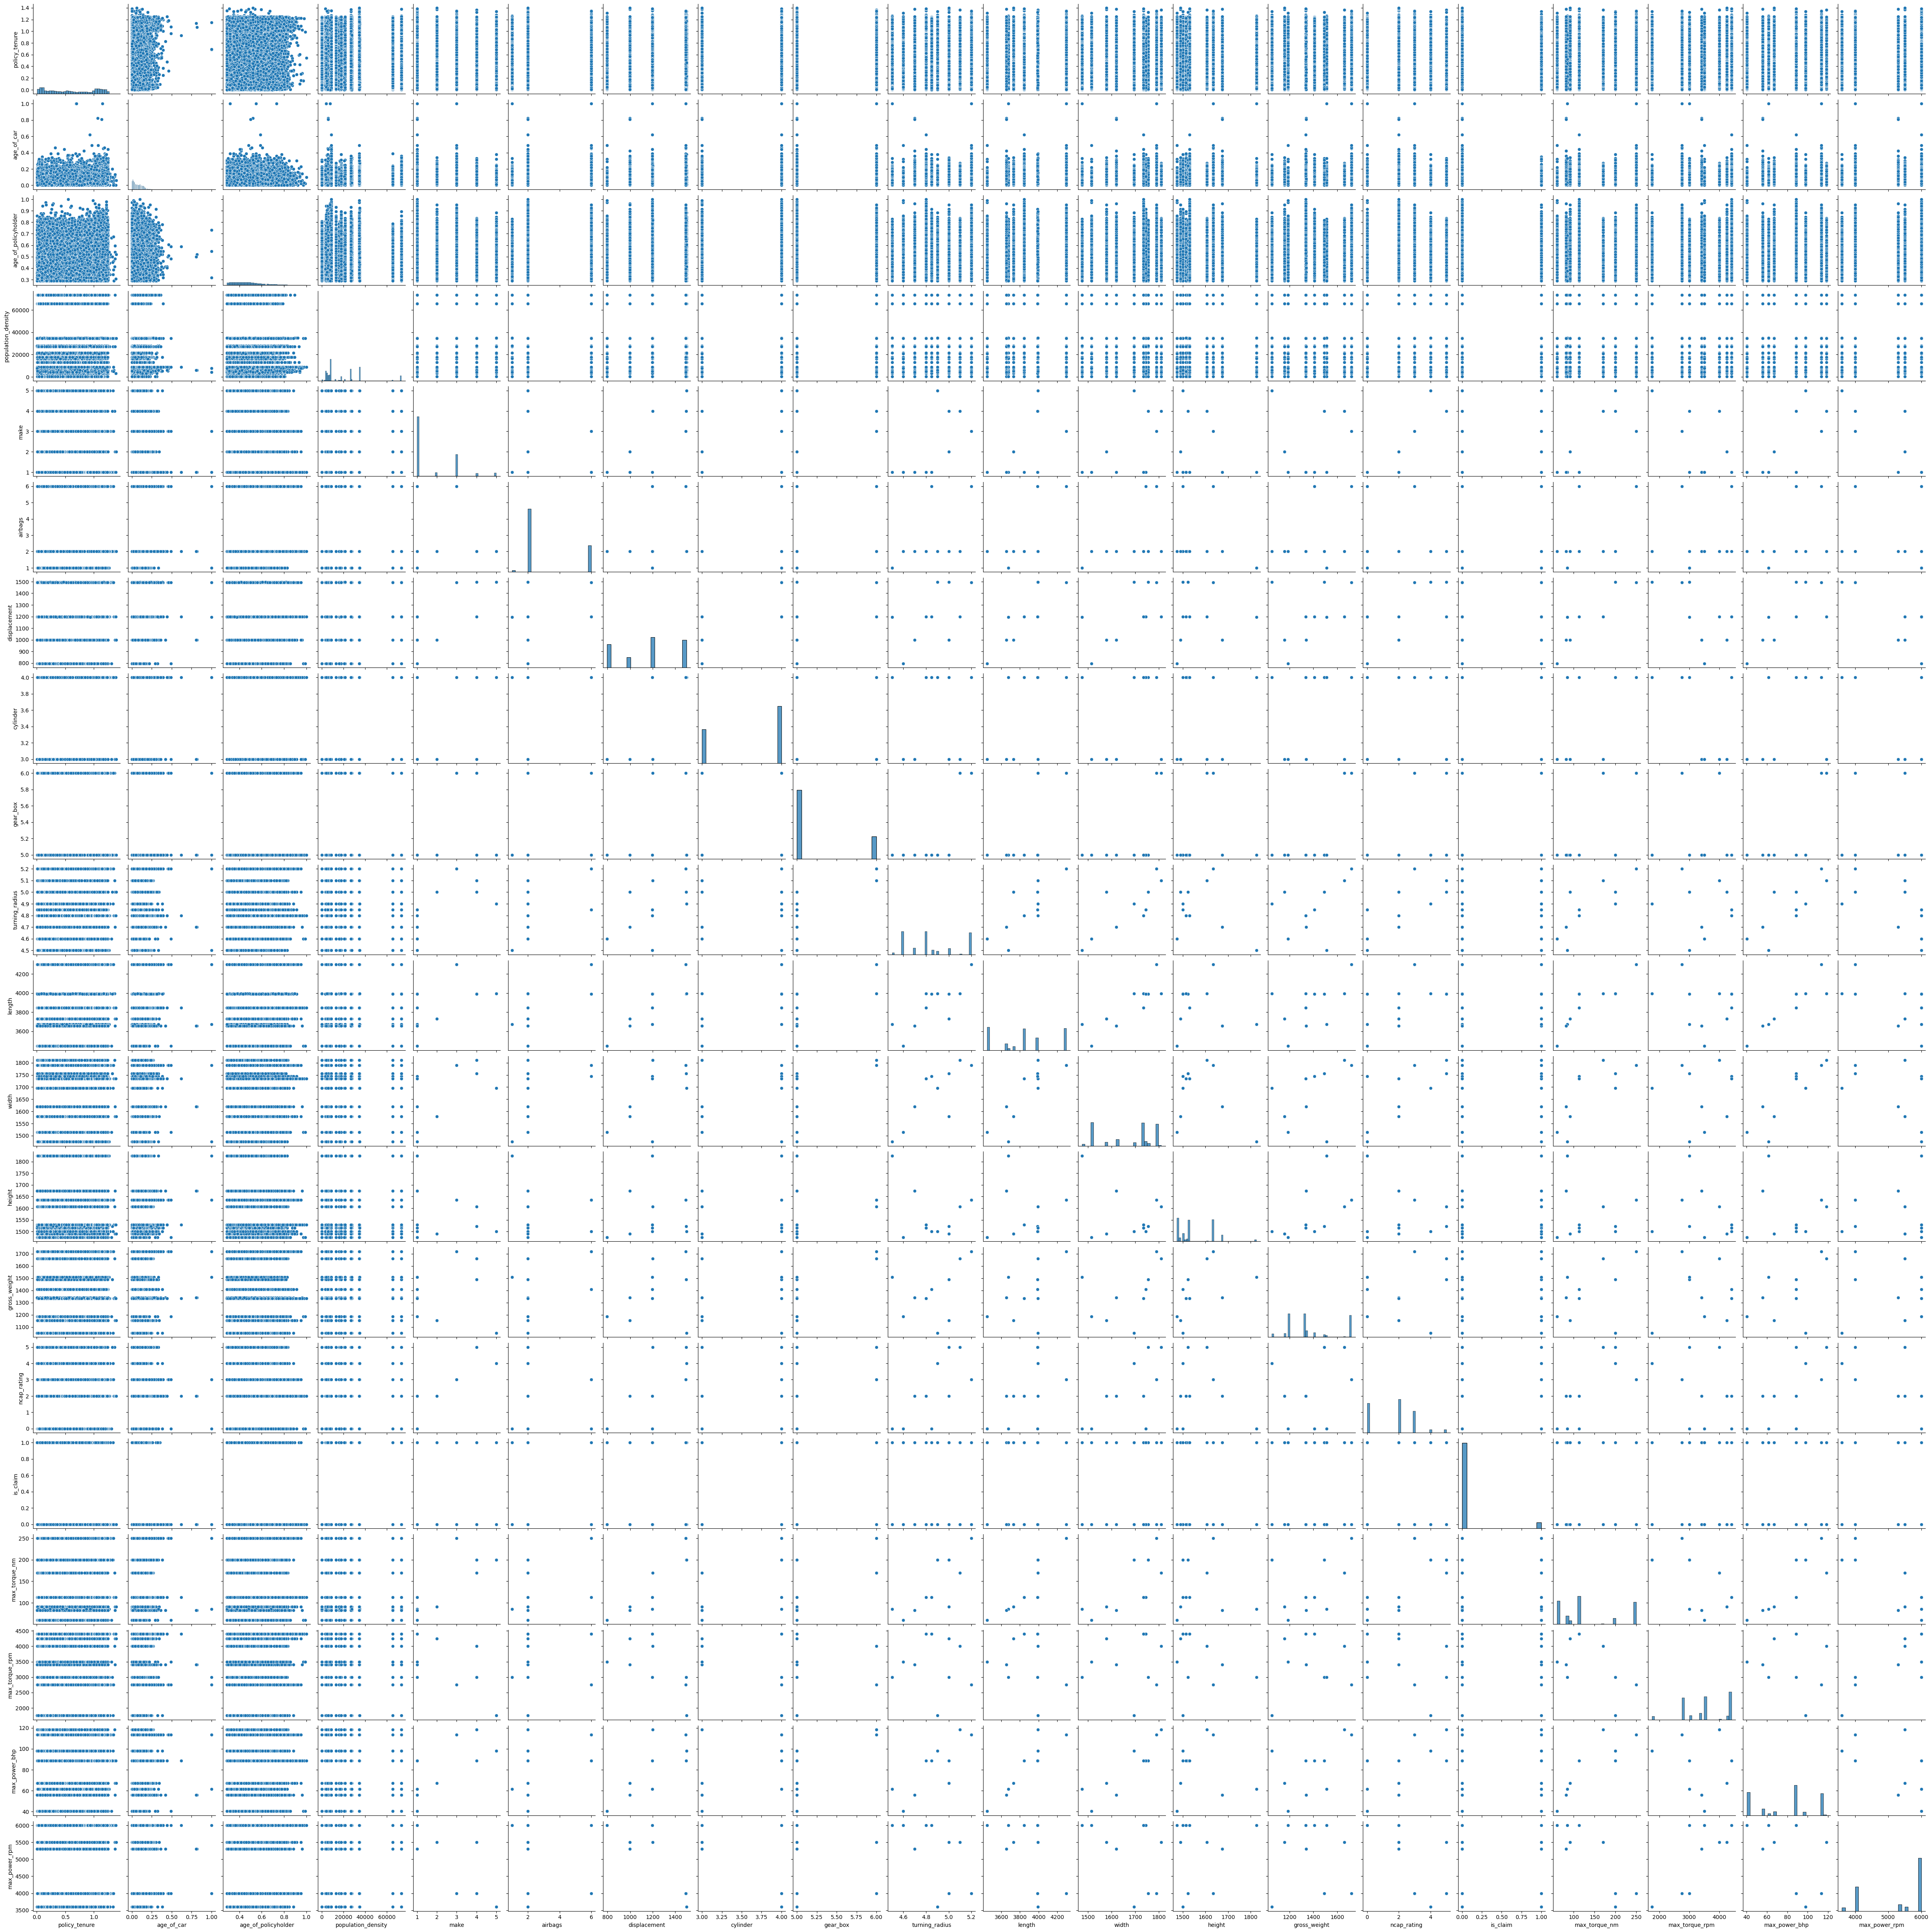

In [133]:
data_cleaned.corr()

# One Hot Encoding

In [12]:
#One hot encoding

data_encoded = oneHotEncoding(data_cleaned, categorical_cols)

data_encoded.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim,max_torque_nm,max_torque_rpm,max_power_bhp,max_power_rpm,area_cluster_C10,area_cluster_C11,area_cluster_C12,area_cluster_C13,area_cluster_C14,area_cluster_C15,area_cluster_C16,area_cluster_C17,area_cluster_C18,area_cluster_C19,area_cluster_C2,area_cluster_C20,area_cluster_C21,area_cluster_C22,area_cluster_C3,area_cluster_C4,area_cluster_C5,area_cluster_C6,area_cluster_C7,area_cluster_C8,area_cluster_C9,segment_B1,segment_B2,segment_C1,segment_C2,segment_Utility,model_M10,model_M11,model_M2,model_M3,model_M4,model_M5,model_M6,model_M7,model_M8,model_M9,fuel_type_Diesel,fuel_type_Petrol,engine_type_1.2 L K Series Engine,engine_type_1.2 L K12N Dualjet,engine_type_1.5 L U2 CRDi,engine_type_1.5 Turbocharged Revotorq,engine_type_1.5 Turbocharged Revotron,engine_type_F8D Petrol Engine,engine_type_G12B,engine_type_K Series Dual jet,engine_type_K10C,engine_type_i-DTEC,is_esc_Yes,is_adjustable_steering_Yes,is_tpms_Yes,is_parking_sensors_Yes,is_parking_camera_Yes,rear_brakes_type_Drum,transmission_type_Manual,steering_type_Manual,steering_type_Power,is_front_fog_lights_Yes,is_rear_window_wiper_Yes,is_rear_window_washer_Yes,is_rear_window_defogger_Yes,is_brake_assist_Yes,is_power_door_locks_Yes,is_central_locking_Yes,is_power_steering_Yes,is_driver_seat_height_adjustable_Yes,is_day_night_rear_view_mirror_Yes,is_ecw_Yes,is_speed_alert_Yes
0,0.515874,0.05,0.644231,4990,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0,60.0,3500,40.36,6000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.672619,0.02,0.375000,27003,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0,60.0,3500,40.36,6000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.841110,0.02,0.384615,4076,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0,60.0,3500,40.36,6000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.900277,0.11,0.432692,21622,1,2,1197,4,5,4.8,3995,1735,1515,1335,2,0,113.0,4400,88.50,6000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,0.596403,0.11,0.634615,34738,2,2,999,3,5,5.0,3731,1579,1490,1155,2,0,91.0,4250,67.06,5500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0


In [13]:
data_encoded.shape

(58592, 89)

In [14]:
#Randomise the dataset

data_sampled = data_encoded.sample(frac=1, random_state=42)

#All features except the target are assigned to 'X'
X = data_sampled.drop("is_claim", axis=1)

#Target feature is assigned to 'Y'
Y = data_sampled["is_claim"]

data_sampled.head()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim,max_torque_nm,max_torque_rpm,max_power_bhp,max_power_rpm,area_cluster_C10,area_cluster_C11,area_cluster_C12,area_cluster_C13,area_cluster_C14,area_cluster_C15,area_cluster_C16,area_cluster_C17,area_cluster_C18,area_cluster_C19,area_cluster_C2,area_cluster_C20,area_cluster_C21,area_cluster_C22,area_cluster_C3,area_cluster_C4,area_cluster_C5,area_cluster_C6,area_cluster_C7,area_cluster_C8,area_cluster_C9,segment_B1,segment_B2,segment_C1,segment_C2,segment_Utility,model_M10,model_M11,model_M2,model_M3,model_M4,model_M5,model_M6,model_M7,model_M8,model_M9,fuel_type_Diesel,fuel_type_Petrol,engine_type_1.2 L K Series Engine,engine_type_1.2 L K12N Dualjet,engine_type_1.5 L U2 CRDi,engine_type_1.5 Turbocharged Revotorq,engine_type_1.5 Turbocharged Revotron,engine_type_F8D Petrol Engine,engine_type_G12B,engine_type_K Series Dual jet,engine_type_K10C,engine_type_i-DTEC,is_esc_Yes,is_adjustable_steering_Yes,is_tpms_Yes,is_parking_sensors_Yes,is_parking_camera_Yes,rear_brakes_type_Drum,transmission_type_Manual,steering_type_Manual,steering_type_Power,is_front_fog_lights_Yes,is_rear_window_wiper_Yes,is_rear_window_washer_Yes,is_rear_window_defogger_Yes,is_brake_assist_Yes,is_power_door_locks_Yes,is_central_locking_Yes,is_power_steering_Yes,is_driver_seat_height_adjustable_Yes,is_day_night_rear_view_mirror_Yes,is_ecw_Yes,is_speed_alert_Yes
29918,0.285690,0.05,0.509615,4076,5,2,1498,4,5,4.9,3995,1695,1501,1051,4,0,200.0,1750,97.89,3600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5034,0.122252,0.05,0.403846,8794,1,2,1197,4,5,4.8,3845,1735,1530,1335,2,0,113.0,4400,88.50,6000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
38100,0.213020,0.03,0.365385,4076,3,6,1493,4,6,5.2,4300,1790,1635,1720,3,0,250.0,2750,113.45,4000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
17050,0.036614,0.00,0.432692,17804,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0,60.0,3500,40.36,6000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
35146,1.041438,0.04,0.576923,8794,1,2,1197,4,5,4.8,3845,1735,1530,1335,2,0,113.0,4400,88.50,6000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# Dataset Rebalancing

Undersampling and Oversampling sampling methods were used for modelling. Results for both methods will be compared to the result of modelling without any sampling method.

Rebalancing is done on the training set only.

In [15]:
#split into train and test

xtrain, xtest, ytrain, ytest = train_test_split(X,Y, test_size=0.3, random_state=None)

In [16]:
#Undersampling

undersampling = RandomUnderSampler(random_state=42)

xtrain_undersampled, ytrain_undersampled = undersampling.fit_resample(xtrain, ytrain)

xtrain_undersampled.shape

(5106, 88)

In [17]:
#Oversampling

oversampling = RandomOverSampler(random_state=42)

xtrain_oversampled, ytrain_oversampled = oversampling.fit_resample(xtrain, ytrain)

xtrain_oversampled.shape

(76922, 88)

In [18]:
#Target column is now balanced

print("Undersampled:\n", ytrain_undersampled.value_counts())

print("\nOversampled:\n", ytrain_oversampled.value_counts())

Undersampled:
 0    2553
1    2553
Name: is_claim, dtype: int64

Oversampled:
 0    38461
1    38461
Name: is_claim, dtype: int64


# Dataset Scaling

Both oversampled and undersampled datasets are scaled and PCA will be applied to them

In [20]:
#Scaling the data - undersampled dataset

scaler_undersampled = StandardScaler()
xtrain_scaled_undersampled = scaler_undersampled.fit_transform(xtrain_undersampled)
xtest_scaled_undersampled = scaler_undersampled.fit_transform(xtest)


xtrain_scaled_undersampled.shape

(5106, 88)

In [22]:
#Scaling the data - oversampled dataset

scaler_oversampled = StandardScaler()
xtrain_scaled_oversampled = scaler_oversampled.fit_transform(xtrain_oversampled)
xtest_scaled_oversampled = scaler_oversampled.fit_transform(xtest)


xtrain_scaled_oversampled.shape

(76922, 88)

# Dimensionality Reduction Using Principal Component Analysis

In [24]:
#PCA - oversampled dataset

pca_undersampled = PCA(84)

xtrain_pca_undersampled = pca_undersampled.fit_transform(xtrain_scaled_undersampled)

xtest_pca_undersampled = pca_undersampled.fit_transform(xtest_scaled_undersampled)

#pca.explained_variance_ratio_

In [26]:
#PCA - oversampled dataset

pca_oversampled = PCA(84)

xtrain_pca_oversampled = pca_oversampled.fit_transform(xtrain_scaled_oversampled)

xtest_pca_oversampled = pca_oversampled.fit_transform(xtest_scaled_oversampled)

#pca.explained_variance_ratio_

# Modelling

Modelling will be done on the dataset after scaling, and the dataset after PCA

In [27]:
#Logistic regresison model - undersampled dataset

reg_undersampled = LogisticRegression()
reg_undersampled.fit(xtrain_pca_undersampled, ytrain_undersampled)

LogisticRegression()

In [28]:
#Logistic regresison model - oversampled dataset

reg_oversampled = LogisticRegression()
reg_oversampled.fit(xtrain_pca_oversampled, ytrain_oversampled)

LogisticRegression()

In [29]:
#Logistic regresison model - no sampling, scaling or PCA done on this dataset

reg = LogisticRegression()
reg.fit(xtrain, ytrain)

LogisticRegression()

In [30]:
#Predictions

predictions_undersampled = reg_undersampled.predict(xtest_pca_undersampled)

predictions_oversampled = reg_oversampled.predict(xtest_pca_oversampled)

predictions = reg.predict(xtest)

# Evaluations

In [31]:
accuracy_undersampled = accuracy_score(ytest, predictions_undersampled)
accuracy_oversampled = accuracy_score(ytest, predictions_oversampled)
accuracy = accuracy_score(ytest, predictions)

print("The following are results of the logistic regression model and different sampling methods\n")
print("Undersampling:", accuracy_undersampled)
print("Oversampling:", accuracy_oversampled)
print("No sampling:", accuracy)

The following are results of the logistic regression model and different sampling methods

Undersampling: 0.5204232563431562
Oversampling: 0.5033564683126636
No sampling: 0.9320172943452042


In [32]:
print(confusion_matrix(ytest, predictions_undersampled))

[[8454 7929]
 [ 501  694]]


In [33]:
print(confusion_matrix(ytest, predictions_oversampled))

[[8161 8222]
 [ 508  687]]


In [34]:
print(confusion_matrix(ytest, predictions))

[[16383     0]
 [ 1195     0]]


# Performance Analysis

In the case of no sampling, the model achieves a high accuracy of 93.2%. However, the confusion matrix reveals a significant issue with class imbalance. The model is effectively predicting only the majority class, with no instances correctly predicted for the minority class. This indicates that the model is not capturing the patterns associated with the minority class, possibly leading to biased results.

Undersampling the majority class results in a dramatic decrease in accuracy to 52.0%. While the model achieves a better balance in predicting both classes, the overall performance is suboptimal. The model struggles to capture the complexity of the data, leading to a large number of false positives and false negatives.

Oversampling the minority class also results in a low accuracy of 50.3%. Despite attempting to address class imbalance, the model's performance remains poor. The confusion matrix indicates that the model continues to struggle with correctly identifying instances of the minority class.

# Conclusion

The imbalanced nature of the dataset poses a significant challenge for the logistic regression model. Class imbalance is particularly evident in the "No Sampling" scenario, where the model tends to favor the majority class.
Both undersampling and oversampling techniques aim to address class imbalance, but their impact on model performance is not positive in this case. The reduced accuracy and suboptimal confusion matrices suggest that the logistic regression model may not be well-suited for capturing the underlying patterns in the data.
Further exploration of more sophisticated algorithms, hyperparameter tuning, or alternative sampling techniques may be necessary to improve model performance. Additionally, considering other evaluation metrics such as precision, recall, and F1-score, especially for the minority class, will provide a more comprehensive understanding of the model's strengths and weaknesses.

# Recommendations

**Explore Different Models:**
Logistic regression might not be the best fit for complex and imbalanced datasets. Other classification algorithms such as decision trees, random forests, support vector machines, or gradient boosting can be explored.


**Ensemble Methods:**
Ensemble methods like Random Forests or Gradient Boosting can often improve predictive performance by combining the strengths of multiple weak models. These methods can handle imbalanced datasets better and provide more robust predictions.


**Hyperparameter Tuning:**
The hyperparameters of the models should be optimised. Grid search or random search can be employed to find the best combination of hyperparameters. Parameters that control class weights can be adjusted to address class imbalance.


**Feature Engineering:**
Feature engineering can significantly impact model performance.


**Cross-Validation:**
Cross-validation can be used to get a more reliable estimate of the model's performance. This helps ensure that the model generalizes well to unseen data.


**Feature Scaling:**

Features should be appropriately and consistently scaled.